In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:128"

import torch
from torch.utils.data import DataLoader
from torch.optim import Adam
from torch.cuda.amp import GradScaler

# Import utils
from utils.Logger import Logger
from utils.Seed import set_seed
from utils.Splitter import stratified_split
from classes.FeatureDataset.CombinedFeatureDataset import CombinedFeatureDataset
from classes.FeatureDataset.WaveformFeatureDataset import WaveformFeatureDataset
from classes.FeatureDataset.ListDataset import ListDataset

# Import XLSR-SLS components (baseline)
from classes.models.XLSR_SLS.model_XLSR_SLS import XLSRSLS
from classes.models.XLSR_SLS.trainer_XLSR_SLS import (
    test_xlsr_sls,
    load_model_xlsr_sls,
    test_xlsr_sls_with_loaders
)

seed = 42
set_seed(42)

# Configure cuDNN for stability and memory efficiency
torch.backends.cudnn.enabled = True  # Re-enable cuDNN but with proper settings
torch.backends.cudnn.benchmark = False  # Disable benchmark to use deterministic algorithms
torch.backends.cudnn.deterministic = True  # Use deterministic algorithms
torch.backends.cudnn.allow_tf32 = False  # Disable TF32 for compatibility

# Set memory allocation configuration to reduce fragmentation
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:128"

device = "cuda" if torch.cuda.is_available() else "cpu"

batch_size = 32
learning_rate = 0.000001
epochs = 30

main_keys = [
    "seen all samples",
    "unseen all samples (UID) w/ Google TTS",
    "unseen all samples (UnID)"
]

/raid/m13521069/RawNets-PF/rawnet-pf/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Waveform (Baseline)

In [2]:
# samples will be stored here:
waveform_test_samples = {
    "spoof elevenmultilingualv2 converted samples": [],
    "spoof elevenmultilingualv2 tts samples": [],
    "spoof dupdub converted samples": [],
    "spoof dupdub tts samples": [],
    "spoof dupdub notindataset tts samples": [],
    "spoof facebookmms converted samples": [],
    "spoof facebookmms tts samples": [],
    "spoof googletts converted samples": [],
    "spoof googletts tts samples": [],
    "spoof vits converted samples": [],
    "spoof vits tts samples": [],
    "bonafide commonvoice samples": [],
    "bonafide prosa samples": [],
    
    "spoof all samples": [],
    "bonafide all samples": [],
    
    "seen all samples": [],
    "unseen all samples (UID)": [],
    "unseen all samples (UID) w/ Google TTS": [],
    "unseen all samples (UnID)": [],
}

# unseen spoof datasets
waveform_spoof_elevenmultilingualv2_converted_dir = "test_preprocessed_data/waveform/Spoof/Converted/ElevenMultilingualV2"
waveform_spoof_elevenmultilingualv2_tts_dir = "test_preprocessed_data/waveform/Spoof/TTS/ElevenMultilingualV2"
waveform_spoof_dupdub_converted_dir = "test_preprocessed_data/waveform/Spoof/Converted/DupDub"
waveform_spoof_dupdub_tts_dir = "test_preprocessed_data/waveform/Spoof/TTS/DupDub"
waveform_spoof_dupdub_notindataset_tts_dir = "test_preprocessed_data/waveform/Spoof/TTS/DupDub-NotInDataset"

# seen spoof datasets
waveform_spoof_facebookmms_converted_dir = "preprocessed_data/waveform/Spoof/Converted/FacebookMMS"
waveform_spoof_facebookmms_tts_dir = "preprocessed_data/waveform/Spoof/TTS/FacebookMMS"
waveform_spoof_googletts_converted_dir = "preprocessed_data/waveform/Spoof/Converted/GoogleTTS"
waveform_spoof_googletts_tts_dir = "preprocessed_data/waveform/Spoof/TTS/GoogleTTS"
waveform_spoof_vits_converted_dir = "preprocessed_data/waveform/Spoof/Converted/VITS"
waveform_spoof_vits_tts_dir = "preprocessed_data/waveform/Spoof/TTS/VITS"

# Bonafide datasets
waveform_bonafide_commonvoice_dir = "preprocessed_data/waveform/Bonafide/CommonVoice"
waveform_bonafide_prosa_dir = "preprocessed_data/waveform/Bonafide/Prosa"

## ------------------------------------
## UNSEEN SPOOF DATASETS
## ------------------------------------

# ElevenMultilingualV2 Converted
if os.path.exists(waveform_spoof_elevenmultilingualv2_converted_dir):
    waveform_spoof_elevenmultilingualv2_converted_dataset = WaveformFeatureDataset(waveform_spoof_elevenmultilingualv2_converted_dir, force_label=0)
    waveform_spoof_elevenmultilingualv2_converted_list = ListDataset([(features, 0) for features, _ in waveform_spoof_elevenmultilingualv2_converted_dataset.samples])
    waveform_test_samples["spoof elevenmultilingualv2 converted samples"].extend(waveform_spoof_elevenmultilingualv2_converted_list)
    waveform_test_samples["spoof all samples"].extend(waveform_spoof_elevenmultilingualv2_converted_list)
    waveform_test_samples["unseen all samples (UID)"].extend(waveform_spoof_elevenmultilingualv2_converted_list)
    waveform_test_samples["unseen all samples (UID) w/ Google TTS"].extend(waveform_spoof_elevenmultilingualv2_converted_list)

    print(f"Loaded {len(waveform_spoof_elevenmultilingualv2_converted_list)} samples from {waveform_spoof_elevenmultilingualv2_converted_dir}")
else:
    print(f"Warning: Directory not found: {waveform_spoof_elevenmultilingualv2_converted_dir}")

# ElevenMultilingualV2 TTS
if os.path.exists(waveform_spoof_elevenmultilingualv2_tts_dir):
    waveform_spoof_elevenmultilingualv2_tts_dataset = WaveformFeatureDataset(waveform_spoof_elevenmultilingualv2_tts_dir, force_label=0)
    waveform_spoof_elevenmultilingualv2_tts_list = ListDataset([(features, 0) for features, _ in waveform_spoof_elevenmultilingualv2_tts_dataset.samples])
    waveform_test_samples["spoof elevenmultilingualv2 tts samples"].extend(waveform_spoof_elevenmultilingualv2_tts_list)
    waveform_test_samples["spoof all samples"].extend(waveform_spoof_elevenmultilingualv2_tts_list)
    waveform_test_samples["unseen all samples (UID)"].extend(waveform_spoof_elevenmultilingualv2_tts_list)
    waveform_test_samples["unseen all samples (UID) w/ Google TTS"].extend(waveform_spoof_elevenmultilingualv2_tts_list)

    print(f"Loaded {len(waveform_spoof_elevenmultilingualv2_tts_list)} samples from {waveform_spoof_elevenmultilingualv2_tts_dir}")
else:
    print(f"Warning: Directory not found: {waveform_spoof_elevenmultilingualv2_tts_dir}")

# DupDub Converted
if os.path.exists(waveform_spoof_dupdub_converted_dir):
    waveform_spoof_dupdub_converted_dataset = WaveformFeatureDataset(waveform_spoof_dupdub_converted_dir, force_label=0)
    waveform_spoof_dupdub_converted_list = ListDataset([(features, 0) for features, _ in waveform_spoof_dupdub_converted_dataset.samples])
    waveform_test_samples["spoof dupdub converted samples"].extend(waveform_spoof_dupdub_converted_list)
    waveform_test_samples["spoof all samples"].extend(waveform_spoof_dupdub_converted_list)
    waveform_test_samples["unseen all samples (UID)"].extend(waveform_spoof_dupdub_converted_list)
    waveform_test_samples["unseen all samples (UID) w/ Google TTS"].extend(waveform_spoof_dupdub_converted_list)

    print(f"Loaded {len(waveform_spoof_dupdub_converted_list)} samples from {waveform_spoof_dupdub_converted_dir}")
else:
    print(f"Warning: Directory not found: {waveform_spoof_dupdub_converted_dir}")

# DupDub TTS
if os.path.exists(waveform_spoof_dupdub_tts_dir):
    waveform_spoof_dupdub_tts_dataset = WaveformFeatureDataset(waveform_spoof_dupdub_tts_dir, force_label=0)
    waveform_spoof_dupdub_tts_list = ListDataset([(features, 0) for features, _ in waveform_spoof_dupdub_tts_dataset.samples])
    waveform_test_samples["spoof dupdub tts samples"].extend(waveform_spoof_dupdub_tts_list)
    waveform_test_samples["spoof all samples"].extend(waveform_spoof_dupdub_tts_list)
    waveform_test_samples["unseen all samples (UID)"].extend(waveform_spoof_dupdub_tts_list)
    waveform_test_samples["unseen all samples (UID) w/ Google TTS"].extend(waveform_spoof_dupdub_tts_list)

    print(f"Loaded {len(waveform_spoof_dupdub_tts_list)} samples from {waveform_spoof_dupdub_tts_dir}")
else:
    print(f"Warning: Directory not found: {waveform_spoof_dupdub_tts_dir}")

# DupDub NotInDataset TTS
if os.path.exists(waveform_spoof_dupdub_notindataset_tts_dir):
    waveform_spoof_dupdub_notindataset_tts_dataset = WaveformFeatureDataset(waveform_spoof_dupdub_notindataset_tts_dir, force_label=0)
    waveform_spoof_dupdub_notindataset_tts_list = ListDataset([(features, 0) for features, _ in waveform_spoof_dupdub_notindataset_tts_dataset.samples])
    waveform_test_samples["spoof dupdub notindataset tts samples"].extend(waveform_spoof_dupdub_notindataset_tts_list)
    waveform_test_samples["spoof all samples"].extend(waveform_spoof_dupdub_notindataset_tts_list)
    waveform_test_samples["unseen all samples (UnID)"].extend(waveform_spoof_dupdub_notindataset_tts_list)
    waveform_test_samples["unseen all samples (UID) w/ Google TTS"].extend(waveform_spoof_dupdub_notindataset_tts_list)

    print(f"Loaded {len(waveform_spoof_dupdub_notindataset_tts_list)} samples from {waveform_spoof_dupdub_notindataset_tts_dir}")
else:
    print(f"Warning: Directory not found: {waveform_spoof_dupdub_notindataset_tts_dir}")

# GoogleTTS TTS
if os.path.exists(waveform_spoof_googletts_tts_dir):
    dataset_waveform_spoof_googletts_tts = WaveformFeatureDataset(waveform_spoof_googletts_tts_dir, force_label=0)
    waveform_spoof_googletts_tts = ListDataset([(features, 0) for features, _ in dataset_waveform_spoof_googletts_tts.samples])
    t_gtt, v_gtt, te_gtt = stratified_split(waveform_spoof_googletts_tts, splits=(0.7, 0.15, 0.15), seed=seed)

    waveform_spoof_googletts_tts_list = ListDataset([waveform_spoof_googletts_tts[i] for i in range(len(te_gtt))])
    waveform_test_samples["spoof googletts tts samples"].extend(waveform_spoof_googletts_tts_list)
    waveform_test_samples["spoof all samples"].extend(waveform_spoof_googletts_tts_list)
    waveform_test_samples["unseen all samples (UID) w/ Google TTS"].extend(waveform_spoof_googletts_tts_list)

    print(f"Loaded {len(waveform_spoof_googletts_tts_list)} samples from {waveform_spoof_googletts_tts_dir}")
else:
    print(f"Warning: Directory not found: {waveform_spoof_googletts_tts_dir}")
    
## ------------------------------------
## SEEN SPOOF DATASETS
## ------------------------------------

# FacebookMMS Converted
if os.path.exists(waveform_spoof_facebookmms_converted_dir):
    dataset_waveform_spoof_facebookmms_converted = WaveformFeatureDataset(waveform_spoof_facebookmms_converted_dir, force_label=0)
    waveform_spoof_facebookmms_converted = ListDataset([(features, 0) for features, _ in dataset_waveform_spoof_facebookmms_converted.samples])
    t_fmc, v_fmc, te_fmc = stratified_split(waveform_spoof_facebookmms_converted, splits=(0.7, 0.15, 0.15), seed=seed)

    waveform_spoof_facebookmms_converted_list = ListDataset([waveform_spoof_facebookmms_converted[i] for i in range(len(te_fmc))])
    waveform_test_samples["spoof facebookmms converted samples"].extend(waveform_spoof_facebookmms_converted_list)
    waveform_test_samples["spoof all samples"].extend(waveform_spoof_facebookmms_converted_list)
    waveform_test_samples["seen all samples"].extend(waveform_spoof_facebookmms_converted_list)

    print(f"Loaded {len(waveform_spoof_facebookmms_converted_list)} samples from {waveform_spoof_facebookmms_converted_dir}")
else:
    print(f"Warning: Directory not found: {waveform_spoof_facebookmms_converted_dir}")

# FacebookMMS TTS
if os.path.exists(waveform_spoof_facebookmms_tts_dir):
    dataset_waveform_spoof_facebookmms_tts = WaveformFeatureDataset(waveform_spoof_facebookmms_tts_dir, force_label=0)
    waveform_spoof_facebookmms_tts = ListDataset([(features, 0) for features, _ in dataset_waveform_spoof_facebookmms_tts.samples])
    t_fmt, v_fmt, te_fmt = stratified_split(waveform_spoof_facebookmms_tts, splits=(0.7, 0.15, 0.15), seed=seed)
    
    waveform_spoof_facebookmms_tts_list = ListDataset([waveform_spoof_facebookmms_tts[i] for i in range(len(te_fmt))])
    waveform_test_samples["spoof facebookmms tts samples"].extend(waveform_spoof_facebookmms_tts_list)
    waveform_test_samples["spoof all samples"].extend(waveform_spoof_facebookmms_tts_list)
    waveform_test_samples["seen all samples"].extend(waveform_spoof_facebookmms_tts_list)

    print(f"Loaded {len(waveform_spoof_facebookmms_tts_list)} samples from {waveform_spoof_facebookmms_tts_dir}")
else:
    print(f"Warning: Directory not found: {waveform_spoof_facebookmms_tts_dir}")

# GoogleTTS Converted
if os.path.exists(waveform_spoof_googletts_converted_dir):
    dataset_waveform_spoof_googletts_converted = WaveformFeatureDataset(waveform_spoof_googletts_converted_dir, force_label=0)
    waveform_spoof_googletts_converted = ListDataset([(features, 0) for features, _ in dataset_waveform_spoof_googletts_converted.samples])
    t_gtc, v_gtc, te_gtc = stratified_split(waveform_spoof_googletts_converted, splits=(0.7, 0.15, 0.15), seed=seed)

    waveform_spoof_googletts_converted_list = ListDataset([waveform_spoof_googletts_converted[i] for i in range(len(te_gtc))])
    waveform_test_samples["spoof googletts converted samples"].extend(waveform_spoof_googletts_converted_list)
    waveform_test_samples["spoof all samples"].extend(waveform_spoof_googletts_converted_list)
    waveform_test_samples["seen all samples"].extend(waveform_spoof_googletts_converted_list)

    print(f"Loaded {len(waveform_spoof_googletts_converted_list)} samples from {waveform_spoof_googletts_converted_dir}")
else:
    print(f"Warning: Directory not found: {waveform_spoof_googletts_converted_dir}")

# VITS Converted
if os.path.exists(waveform_spoof_vits_converted_dir):
    dataset_waveform_spoof_vits_converted = WaveformFeatureDataset(waveform_spoof_vits_converted_dir, force_label=0)
    waveform_spoof_vits_converted = ListDataset([(features, 0) for features, _ in dataset_waveform_spoof_vits_converted.samples])
    t_vc, v_vc, te_vc = stratified_split(waveform_spoof_vits_converted, splits=(0.7, 0.15, 0.15), seed=seed)

    waveform_spoof_vits_converted_list = ListDataset([waveform_spoof_vits_converted[i] for i in range(len(te_vc))])
    waveform_test_samples["spoof vits converted samples"].extend(waveform_spoof_vits_converted_list)
    waveform_test_samples["spoof all samples"].extend(waveform_spoof_vits_converted_list)
    waveform_test_samples["seen all samples"].extend(waveform_spoof_vits_converted_list)

    print(f"Loaded {len(waveform_spoof_vits_converted_list)} samples from {waveform_spoof_vits_converted_dir}")
else:
    print(f"Warning: Directory not found: {waveform_spoof_vits_converted_dir}")

# VITS TTS
if os.path.exists(waveform_spoof_vits_tts_dir):
    dataset_waveform_spoof_vits_tts = WaveformFeatureDataset(waveform_spoof_vits_tts_dir, force_label=0)
    waveform_spoof_vits_tts = ListDataset([(features, 0) for features, _ in dataset_waveform_spoof_vits_tts.samples])
    t_vt, v_vt, te_vt = stratified_split(waveform_spoof_vits_tts, splits=(0.7, 0.15, 0.15), seed=seed)

    waveform_spoof_vits_tts_list = ListDataset([waveform_spoof_vits_tts[i] for i in range(len(te_vt))])
    waveform_test_samples["spoof vits tts samples"].extend(waveform_spoof_vits_tts_list)
    waveform_test_samples["spoof all samples"].extend(waveform_spoof_vits_tts_list)
    waveform_test_samples["seen all samples"].extend(waveform_spoof_vits_tts_list)

    print(f"Loaded {len(waveform_spoof_vits_tts_list)} samples from {waveform_spoof_vits_tts_dir}")
else:
    print(f"Warning: Directory not found: {waveform_spoof_vits_tts_dir}")

### Bonafides
# Bonafide CommonVoice
if os.path.exists(waveform_bonafide_commonvoice_dir):
    dataset_commonvoice = WaveformFeatureDataset(waveform_bonafide_commonvoice_dir, force_label=1)
    waveform_bonafide_commonvoice = ListDataset([(features, 1) for features, _ in dataset_commonvoice.samples])
    t_c, v_c, te_c = stratified_split(waveform_bonafide_commonvoice, splits=(0.7, 0.15, 0.15), seed=seed)

    waveform_bonafide_commonvoice_list = ListDataset([waveform_bonafide_commonvoice[i] for i in range(len(te_c))])
    waveform_test_samples["bonafide commonvoice samples"].extend(waveform_bonafide_commonvoice_list)
    waveform_test_samples["bonafide all samples"].extend(waveform_bonafide_commonvoice_list)
    waveform_test_samples["seen all samples"].extend(waveform_bonafide_commonvoice_list)
    waveform_test_samples["unseen all samples (UID)"].extend(waveform_bonafide_commonvoice_list)
    waveform_test_samples["unseen all samples (UID) w/ Google TTS"].extend(waveform_bonafide_commonvoice_list)
    waveform_test_samples["unseen all samples (UnID)"].extend(waveform_bonafide_commonvoice_list)

    print(f"Loaded {len(waveform_bonafide_commonvoice_list)} samples from {waveform_bonafide_commonvoice_dir}")
else:
    print(f"Warning: Directory not found: {waveform_bonafide_commonvoice_dir}")

# Bonafide Prosa
if os.path.exists(waveform_bonafide_prosa_dir):
    dataset_prosa = WaveformFeatureDataset(waveform_bonafide_prosa_dir, force_label=1)
    waveform_bonafide_prosa = ListDataset([(features, 1) for features, _ in dataset_prosa.samples])
    t_p, v_p, te_p = stratified_split(waveform_bonafide_prosa, splits=(0.7, 0.15, 0.15), seed=seed)

    waveform_bonafide_prosa_list = ListDataset([waveform_bonafide_prosa[i] for i in range(len(te_p))])
    waveform_test_samples["bonafide prosa samples"].extend(waveform_bonafide_prosa_list)
    waveform_test_samples["bonafide all samples"].extend(waveform_bonafide_prosa_list)
    waveform_test_samples["seen all samples"].extend(waveform_bonafide_prosa_list)
    waveform_test_samples["unseen all samples (UID)"].extend(waveform_bonafide_prosa_list)
    waveform_test_samples["unseen all samples (UID) w/ Google TTS"].extend(waveform_bonafide_prosa_list)
    waveform_test_samples["unseen all samples (UnID)"].extend(waveform_bonafide_prosa_list)

    print(f"Loaded {len(waveform_bonafide_prosa_list)} samples from {waveform_bonafide_prosa_dir}")
else:
    print(f"Warning: Directory not found: {waveform_bonafide_prosa_dir}")

print("-----------------------------------------------")
print(f"Total test spoof samples: {len(waveform_test_samples['spoof all samples'])}")
print(f"Total test bonafide samples: {len(waveform_test_samples['bonafide all samples'])}")
print("-----------------------------------------------")
print(f"Total seen test spoof samples: {len(waveform_test_samples['seen all samples'])}")
print(f"Total unseen UID samples: {len(waveform_test_samples['unseen all samples (UID)'])}")
print(f"Total unseen UnID samples: {len(waveform_test_samples['unseen all samples (UnID)'])}")
print("-----------------------------------------------")

# Use smaller batch size for testing to reduce memory usage
# This is more efficient than creating large batches and chunking them
test_batch_size = 1  # Reduced from 32 to match memory constraints

waveform_test_samples_dataloaders = {
    key: DataLoader(value, batch_size=test_batch_size, shuffle=False, num_workers=4)
    for key, value in waveform_test_samples.items()
}

Skipped 0 files due to NaNs/Infs.
Loaded 746 samples from test_preprocessed_data/waveform/Spoof/Converted/ElevenMultilingualV2
Skipped 0 files due to NaNs/Infs.
Loaded 751 samples from test_preprocessed_data/waveform/Spoof/TTS/ElevenMultilingualV2
Skipped 0 files due to NaNs/Infs.
Loaded 53 samples from test_preprocessed_data/waveform/Spoof/Converted/DupDub
Skipped 0 files due to NaNs/Infs.
Loaded 101 samples from test_preprocessed_data/waveform/Spoof/TTS/DupDub
Skipped 0 files due to NaNs/Infs.
Loaded 111 samples from test_preprocessed_data/waveform/Spoof/TTS/DupDub-NotInDataset
Skipped 0 files due to NaNs/Infs.
Loaded 2461 samples from preprocessed_data/waveform/Spoof/TTS/GoogleTTS
Skipped 0 files due to NaNs/Infs.
Loaded 1249 samples from preprocessed_data/waveform/Spoof/Converted/FacebookMMS
Skipped 0 files due to NaNs/Infs.
Loaded 2517 samples from preprocessed_data/waveform/Spoof/TTS/FacebookMMS
Skipped 0 files due to NaNs/Infs.
Loaded 1225 samples from preprocessed_data/waveform

## XLSR-SLS (Baseline)

Loading pretrained XLSR model from: xlsr2_300m.pt
Checkpoint keys: dict_keys(['cfg', 'args', 'model', 'optimizer_history', 'extra_state', 'last_optimizer_state'])
✗ Strategy 1 failed: AttributeError
Trying Strategy 2: Direct model construction...
✗ Strategy 2 failed: TypeError
Trying Strategy 3: Using transformers library...
✓ Successfully loaded with transformers library
Note: Using Hugging Face model instead of local checkpoint
Detected Hugging Face Transformers model
SSL model will be fine-tuned (fine_tune_ssl=True)
Loaded model from pretrained_weights/waveform/XLSR_SLS/xlsr_sls_waveform-ep_30-bs_32-lr_1e-06.pth (epoch 29)
Testing spoof elevenmultilingualv2 converted samples
Initialized fc1 with input size: 22506


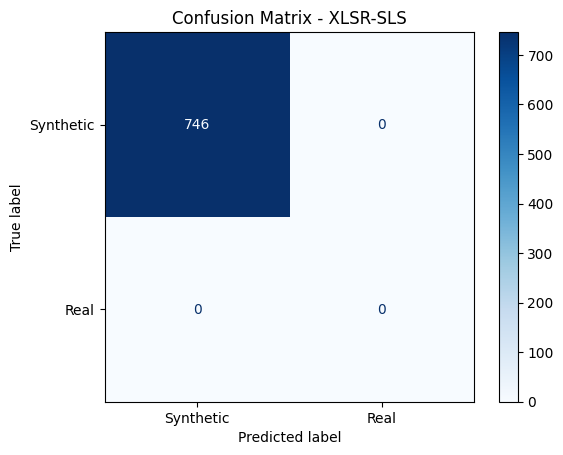

Testing spoof elevenmultilingualv2 tts samples


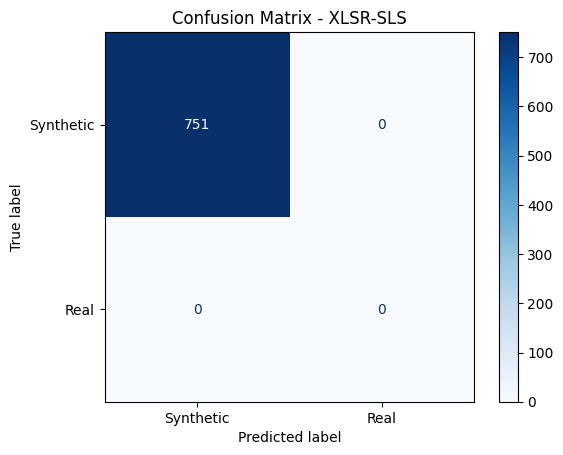

Testing spoof dupdub converted samples


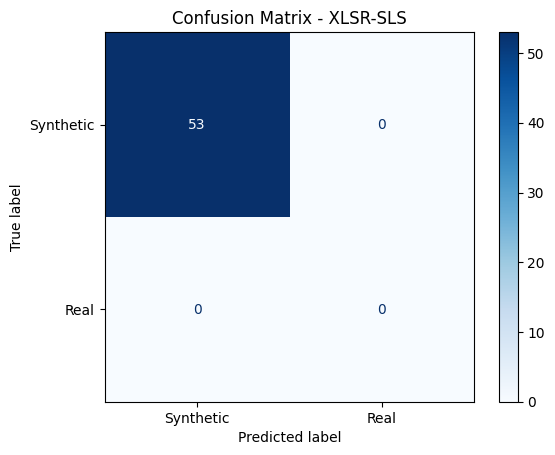

Testing spoof dupdub tts samples


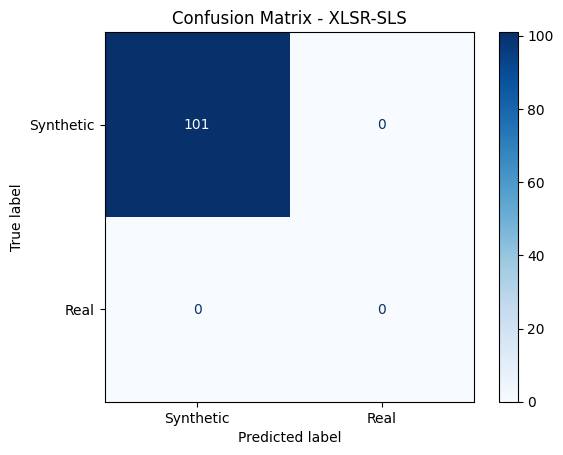

Testing spoof dupdub notindataset tts samples


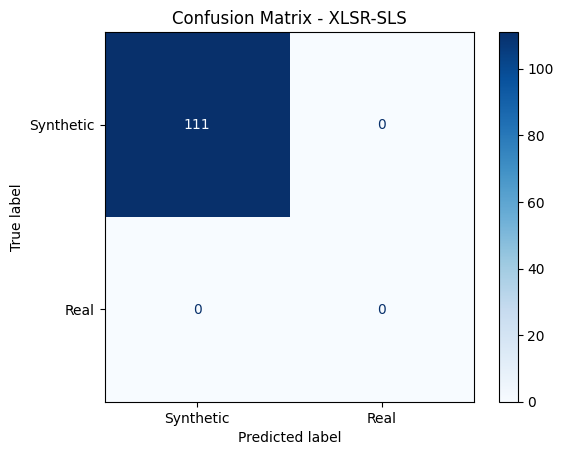

Testing spoof facebookmms converted samples


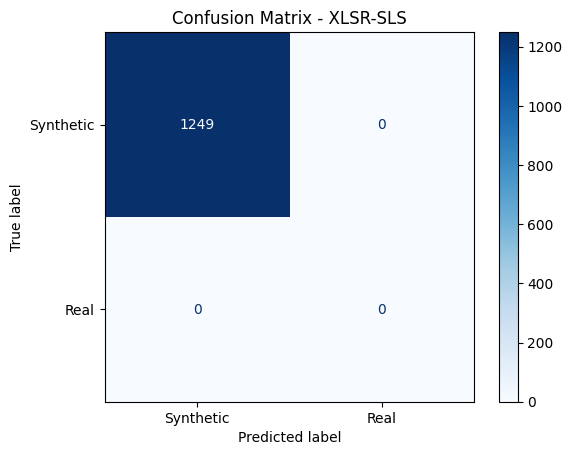

Testing spoof facebookmms tts samples


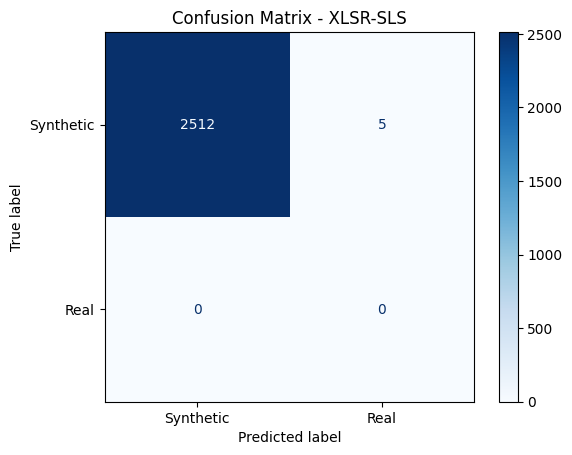

Testing spoof googletts converted samples


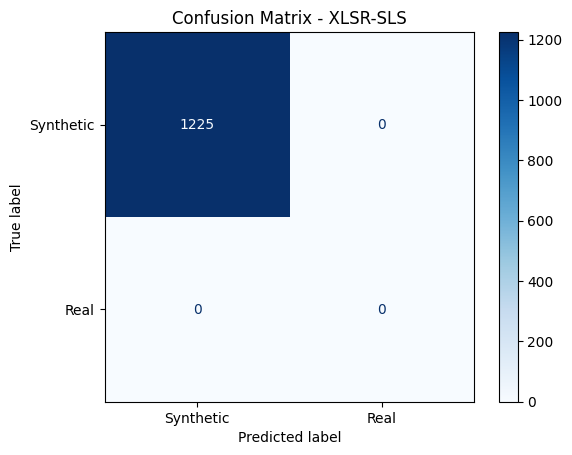

Testing spoof googletts tts samples


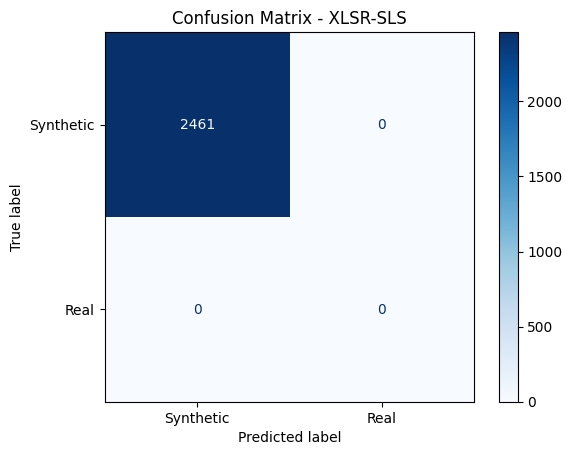

Testing spoof vits converted samples


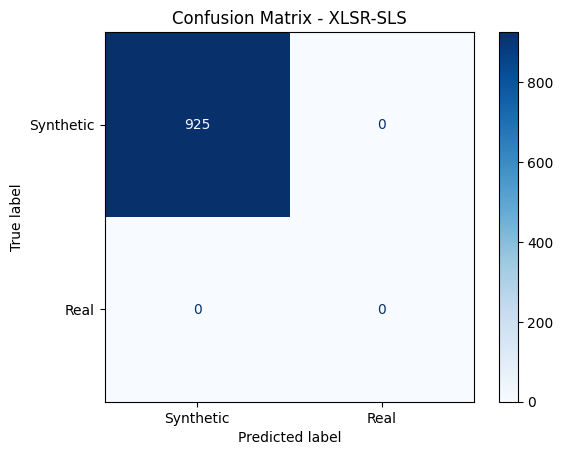

Testing spoof vits tts samples


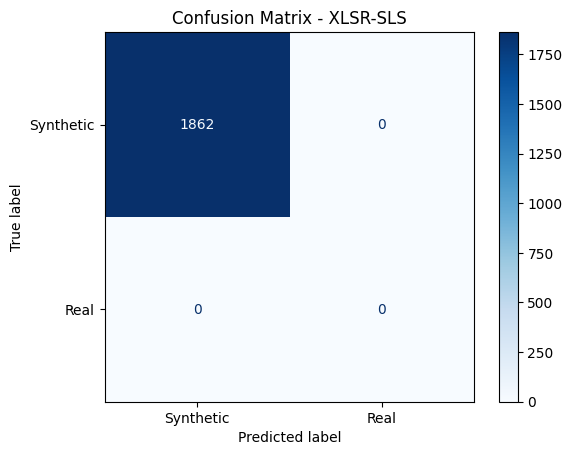

Testing bonafide commonvoice samples


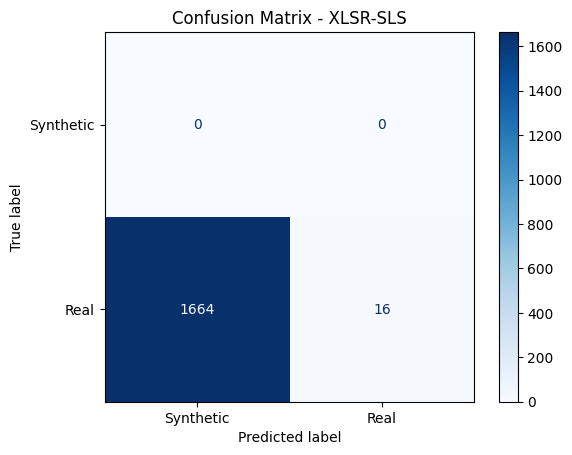

Testing bonafide prosa samples


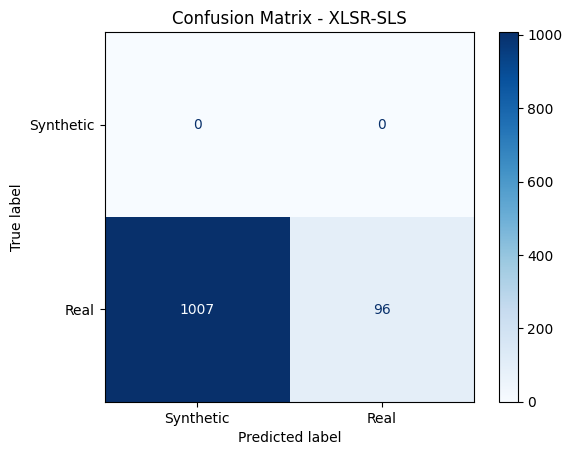

Testing spoof all samples


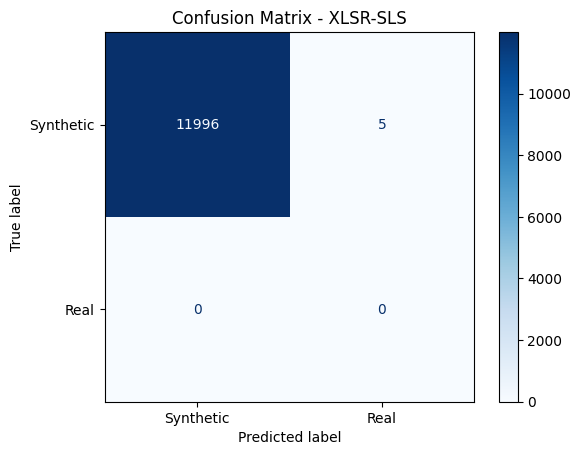

Testing bonafide all samples


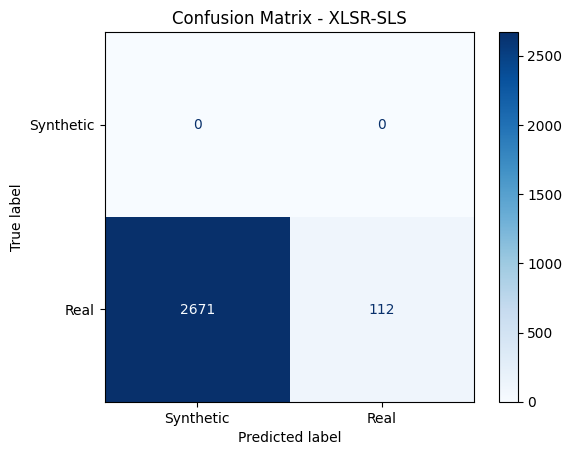

Testing seen all samples
              --> Test Acc: 74.66%
              --> Balanced Acc: 0.5198 | Precision: 0.9573
              --> Recall: 0.0402 | F1: 0.0772 | F2: 0.0498
              --> EER: 0.2232 | actDCF: 1.0000 | minDCF: 0.4433
              --> CLLR: 0.9525


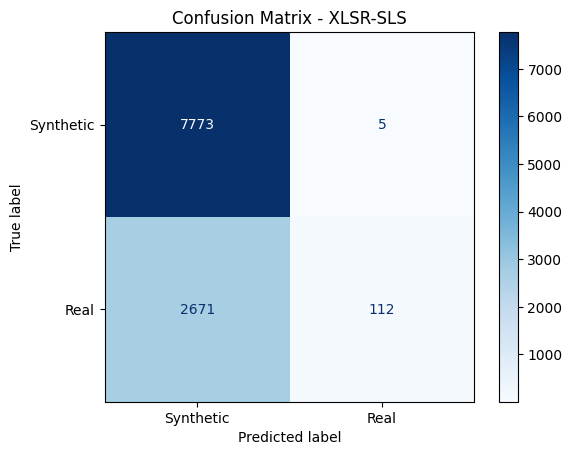

Testing unseen all samples (UID)


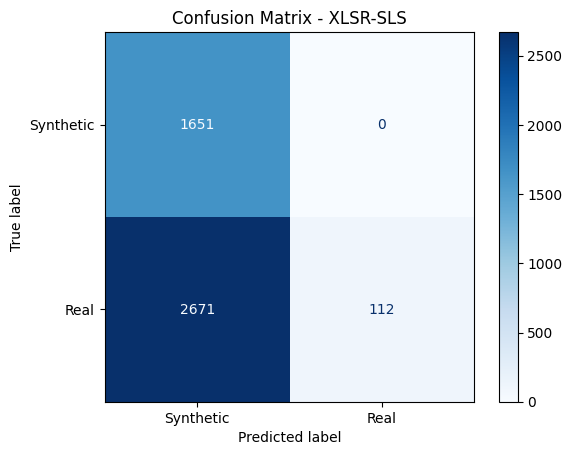

Testing unseen all samples (UID) w/ Google TTS
              --> Test Acc: 61.88%
              --> Balanced Acc: 0.5201 | Precision: 1.0000
              --> Recall: 0.0402 | F1: 0.0774 | F2: 0.0498
              --> EER: 0.1536 | actDCF: 1.0000 | minDCF: 0.3049
              --> CLLR: 0.9292


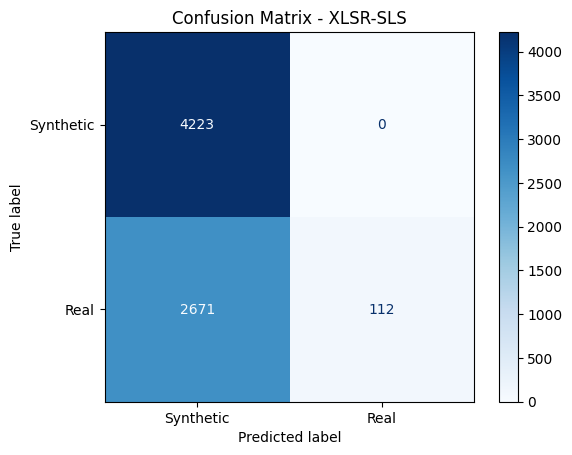

Testing unseen all samples (UnID)
              --> Test Acc: 7.71%
              --> Balanced Acc: 0.5201 | Precision: 1.0000
              --> Recall: 0.0402 | F1: 0.0774 | F2: 0.0498
              --> EER: 0.1062 | actDCF: 1.0000 | minDCF: 0.1978
              --> CLLR: 0.9166


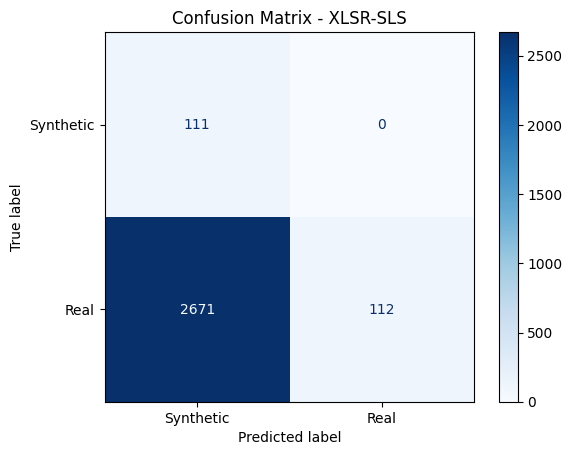

In [3]:
# Model configuration
xlsr_sls_model_config = {
    'cp_path': 'xlsr2_300m.pt',  # Path to pretrained XLSR model
    'fine_tune_ssl': True        # Whether to fine-tune SSL model
}

device = "cuda" if torch.cuda.is_available() else "cpu"

# --- Set up model, optimizer, and scaler ---
model = XLSRSLS(xlsr_sls_model_config, device).to(device)
optimizer = Adam(model.parameters(), lr=learning_rate)
scaler = GradScaler()

# --- Load the model ---
start_epoch = load_model_xlsr_sls(
    model, optimizer, scaler,
    path=r"pretrained_weights/waveform/XLSR_SLS/xlsr_sls_waveform-ep_30-bs_32-lr_1e-06.pth",
    device=device
)

for key, test_sample in waveform_test_samples_dataloaders.items():
    print(f"Testing {key}")
    if key in main_keys:
        predictions, targets, metrics = test_xlsr_sls(model, test_sample, device=device)
    else:
        predictions = test_xlsr_sls_with_loaders(model, test_sample, device=device)
    torch.cuda.empty_cache()

# Combined (Diff Pipeline)

In [4]:
# samples will be stored here:
combined_test_samples = {
    "spoof elevenmultilingualv2 converted samples": [],
    "spoof elevenmultilingualv2 tts samples": [],
    "spoof dupdub converted samples": [],
    "spoof dupdub tts samples": [],
    "spoof dupdub notindataset tts samples": [],
    "spoof facebookmms converted samples": [],
    "spoof facebookmms tts samples": [],
    "spoof googletts converted samples": [],
    "spoof googletts tts samples": [],
    "spoof vits converted samples": [],
    "spoof vits tts samples": [],
    "bonafide commonvoice samples": [],
    "bonafide prosa samples": [],
    
    "spoof all samples": [],
    "bonafide all samples": [],
    
    "seen all samples": [],
    "unseen all samples (UID)": [],
    "unseen all samples (UID) w/ Google TTS": [],
    "unseen all samples (UnID)": [],
}

# unseen spoof datasets
combined_spoof_elevenmultilingualv2_converted_dir = "test_preprocessed_data/combined/Spoof/Converted/ElevenMultilingualV2"
combined_spoof_elevenmultilingualv2_tts_dir = "test_preprocessed_data/combined/Spoof/TTS/ElevenMultilingualV2"
combined_spoof_dupdub_converted_dir = "test_preprocessed_data/combined/Spoof/Converted/DupDub"
combined_spoof_dupdub_tts_dir = "test_preprocessed_data/combined/Spoof/TTS/DupDub"
combined_spoof_dupdub_notindataset_tts_dir = "test_preprocessed_data/combined/Spoof/TTS/DupDub-NotInDataset"

# seen spoof datasets
combined_spoof_facebookmms_converted_dir = "preprocessed_data/combined/Spoof/Converted/FacebookMMS"
combined_spoof_facebookmms_tts_dir = "preprocessed_data/combined/Spoof/TTS/FacebookMMS"
combined_spoof_googletts_converted_dir = "preprocessed_data/combined/Spoof/Converted/GoogleTTS"
combined_spoof_googletts_tts_dir = "preprocessed_data/combined/Spoof/TTS/GoogleTTS"
combined_spoof_vits_converted_dir = "preprocessed_data/combined/Spoof/Converted/VITS"
combined_spoof_vits_tts_dir = "preprocessed_data/combined/Spoof/TTS/VITS"

# Bonafide datasets
combined_bonafide_commonvoice_dir = "preprocessed_data/combined/Bonafide/CommonVoice"
combined_bonafide_prosa_dir = "preprocessed_data/combined/Bonafide/Prosa"

## ------------------------------------
## UNSEEN SPOOF DATASETS
## ------------------------------------

# ElevenMultilingualV2 Converted
if os.path.exists(combined_spoof_elevenmultilingualv2_converted_dir):
    combined_spoof_elevenmultilingualv2_converted_dataset = CombinedFeatureDataset(combined_spoof_elevenmultilingualv2_converted_dir, force_label=0)
    combined_spoof_elevenmultilingualv2_converted_list = ListDataset([(features, 0) for features, _ in combined_spoof_elevenmultilingualv2_converted_dataset.samples])
    combined_test_samples["spoof elevenmultilingualv2 converted samples"].extend(combined_spoof_elevenmultilingualv2_converted_list)
    combined_test_samples["spoof all samples"].extend(combined_spoof_elevenmultilingualv2_converted_list)
    combined_test_samples["unseen all samples (UID)"].extend(combined_spoof_elevenmultilingualv2_converted_list)
    combined_test_samples["unseen all samples (UID) w/ Google TTS"].extend(combined_spoof_elevenmultilingualv2_converted_list)

    print(f"Loaded {len(combined_spoof_elevenmultilingualv2_converted_list)} samples from {combined_spoof_elevenmultilingualv2_converted_dir}")
else:
    print(f"Warning: Directory not found: {combined_spoof_elevenmultilingualv2_converted_dir}")

# ElevenMultilingualV2 TTS
if os.path.exists(combined_spoof_elevenmultilingualv2_tts_dir):
    combined_spoof_elevenmultilingualv2_tts_dataset = CombinedFeatureDataset(combined_spoof_elevenmultilingualv2_tts_dir, force_label=0)
    combined_spoof_elevenmultilingualv2_tts_list = ListDataset([(features, 0) for features, _ in combined_spoof_elevenmultilingualv2_tts_dataset.samples])
    combined_test_samples["spoof elevenmultilingualv2 tts samples"].extend(combined_spoof_elevenmultilingualv2_tts_list)
    combined_test_samples["spoof all samples"].extend(combined_spoof_elevenmultilingualv2_tts_list)
    combined_test_samples["unseen all samples (UID)"].extend(combined_spoof_elevenmultilingualv2_tts_list)
    combined_test_samples["unseen all samples (UID) w/ Google TTS"].extend(combined_spoof_elevenmultilingualv2_tts_list)

    print(f"Loaded {len(combined_spoof_elevenmultilingualv2_tts_list)} samples from {combined_spoof_elevenmultilingualv2_tts_dir}")
else:
    print(f"Warning: Directory not found: {combined_spoof_elevenmultilingualv2_tts_dir}")

# DupDub Converted
if os.path.exists(combined_spoof_dupdub_converted_dir):
    combined_spoof_dupdub_converted_dataset = CombinedFeatureDataset(combined_spoof_dupdub_converted_dir, force_label=0)
    combined_spoof_dupdub_converted_list = ListDataset([(features, 0) for features, _ in combined_spoof_dupdub_converted_dataset.samples])
    combined_test_samples["spoof dupdub converted samples"].extend(combined_spoof_dupdub_converted_list)
    combined_test_samples["spoof all samples"].extend(combined_spoof_dupdub_converted_list)
    combined_test_samples["unseen all samples (UID)"].extend(combined_spoof_dupdub_converted_list)
    combined_test_samples["unseen all samples (UID) w/ Google TTS"].extend(combined_spoof_dupdub_converted_list)

    print(f"Loaded {len(combined_spoof_dupdub_converted_list)} samples from {combined_spoof_dupdub_converted_dir}")
else:
    print(f"Warning: Directory not found: {combined_spoof_dupdub_converted_dir}")

# DupDub TTS
if os.path.exists(combined_spoof_dupdub_tts_dir):
    combined_spoof_dupdub_tts_dataset = CombinedFeatureDataset(combined_spoof_dupdub_tts_dir, force_label=0)
    combined_spoof_dupdub_tts_list = ListDataset([(features, 0) for features, _ in combined_spoof_dupdub_tts_dataset.samples])
    combined_test_samples["spoof dupdub tts samples"].extend(combined_spoof_dupdub_tts_list)
    combined_test_samples["spoof all samples"].extend(combined_spoof_dupdub_tts_list)
    combined_test_samples["unseen all samples (UID)"].extend(combined_spoof_dupdub_tts_list)
    combined_test_samples["unseen all samples (UID) w/ Google TTS"].extend(combined_spoof_dupdub_tts_list)

    print(f"Loaded {len(combined_spoof_dupdub_tts_list)} samples from {combined_spoof_dupdub_tts_dir}")
else:
    print(f"Warning: Directory not found: {combined_spoof_dupdub_tts_dir}")

# DupDub NotInDataset TTS
if os.path.exists(combined_spoof_dupdub_notindataset_tts_dir):
    combined_spoof_dupdub_notindataset_tts_dataset = CombinedFeatureDataset(combined_spoof_dupdub_notindataset_tts_dir, force_label=0)
    combined_spoof_dupdub_notindataset_tts_list = ListDataset([(features, 0) for features, _ in combined_spoof_dupdub_notindataset_tts_dataset.samples])
    combined_test_samples["spoof dupdub notindataset tts samples"].extend(combined_spoof_dupdub_notindataset_tts_list)
    combined_test_samples["spoof all samples"].extend(combined_spoof_dupdub_notindataset_tts_list)
    combined_test_samples["unseen all samples (UnID)"].extend(combined_spoof_dupdub_notindataset_tts_list)
    combined_test_samples["unseen all samples (UID) w/ Google TTS"].extend(combined_spoof_dupdub_notindataset_tts_list)

    print(f"Loaded {len(combined_spoof_dupdub_notindataset_tts_list)} samples from {combined_spoof_dupdub_notindataset_tts_dir}")
else:
    print(f"Warning: Directory not found: {combined_spoof_dupdub_notindataset_tts_dir}")

# GoogleTTS TTS
if os.path.exists(combined_spoof_googletts_tts_dir):
    dataset_combined_spoof_googletts_tts = CombinedFeatureDataset(combined_spoof_googletts_tts_dir, force_label=0)
    combined_spoof_googletts_tts = ListDataset([(features, 0) for features, _ in dataset_combined_spoof_googletts_tts.samples])
    t_gtt, v_gtt, te_gtt = stratified_split(combined_spoof_googletts_tts, splits=(0.7, 0.15, 0.15), seed=seed)

    combined_spoof_googletts_tts_list = ListDataset([combined_spoof_googletts_tts[i] for i in range(len(te_gtt))])
    combined_test_samples["spoof googletts tts samples"].extend(combined_spoof_googletts_tts_list)
    combined_test_samples["spoof all samples"].extend(combined_spoof_googletts_tts_list)
    combined_test_samples["unseen all samples (UID) w/ Google TTS"].extend(combined_spoof_googletts_tts_list)

    print(f"Loaded {len(combined_spoof_googletts_tts_list)} samples from {combined_spoof_googletts_tts_dir}")
else:
    print(f"Warning: Directory not found: {combined_spoof_googletts_tts_dir}")
    
## ------------------------------------
## SEEN SPOOF DATASETS
## ------------------------------------

# FacebookMMS Converted
if os.path.exists(combined_spoof_facebookmms_converted_dir):
    dataset_combined_spoof_facebookmms_converted = CombinedFeatureDataset(combined_spoof_facebookmms_converted_dir, force_label=0)
    combined_spoof_facebookmms_converted = ListDataset([(features, 0) for features, _ in dataset_combined_spoof_facebookmms_converted.samples])
    t_fmc, v_fmc, te_fmc = stratified_split(combined_spoof_facebookmms_converted, splits=(0.7, 0.15, 0.15), seed=seed)

    combined_spoof_facebookmms_converted_list = ListDataset([combined_spoof_facebookmms_converted[i] for i in range(len(te_fmc))])
    combined_test_samples["spoof facebookmms converted samples"].extend(combined_spoof_facebookmms_converted_list)
    combined_test_samples["spoof all samples"].extend(combined_spoof_facebookmms_converted_list)
    combined_test_samples["seen all samples"].extend(combined_spoof_facebookmms_converted_list)

    print(f"Loaded {len(combined_spoof_facebookmms_converted_list)} samples from {combined_spoof_facebookmms_converted_dir}")
else:
    print(f"Warning: Directory not found: {combined_spoof_facebookmms_converted_dir}")

# FacebookMMS TTS
if os.path.exists(combined_spoof_facebookmms_tts_dir):
    dataset_combined_spoof_facebookmms_tts = CombinedFeatureDataset(combined_spoof_facebookmms_tts_dir, force_label=0)
    combined_spoof_facebookmms_tts = ListDataset([(features, 0) for features, _ in dataset_combined_spoof_facebookmms_tts.samples])
    t_fmt, v_fmt, te_fmt = stratified_split(combined_spoof_facebookmms_tts, splits=(0.7, 0.15, 0.15), seed=seed)
    
    combined_spoof_facebookmms_tts_list = ListDataset([combined_spoof_facebookmms_tts[i] for i in range(len(te_fmt))])
    combined_test_samples["spoof facebookmms tts samples"].extend(combined_spoof_facebookmms_tts_list)
    combined_test_samples["spoof all samples"].extend(combined_spoof_facebookmms_tts_list)
    combined_test_samples["seen all samples"].extend(combined_spoof_facebookmms_tts_list)

    print(f"Loaded {len(combined_spoof_facebookmms_tts_list)} samples from {combined_spoof_facebookmms_tts_dir}")
else:
    print(f"Warning: Directory not found: {combined_spoof_facebookmms_tts_dir}")

# GoogleTTS Converted
if os.path.exists(combined_spoof_googletts_converted_dir):
    dataset_combined_spoof_googletts_converted = CombinedFeatureDataset(combined_spoof_googletts_converted_dir, force_label=0)
    combined_spoof_googletts_converted = ListDataset([(features, 0) for features, _ in dataset_combined_spoof_googletts_converted.samples])
    t_gtc, v_gtc, te_gtc = stratified_split(combined_spoof_googletts_converted, splits=(0.7, 0.15, 0.15), seed=seed)

    combined_spoof_googletts_converted_list = ListDataset([combined_spoof_googletts_converted[i] for i in range(len(te_gtc))])
    combined_test_samples["spoof googletts converted samples"].extend(combined_spoof_googletts_converted_list)
    combined_test_samples["spoof all samples"].extend(combined_spoof_googletts_converted_list)
    combined_test_samples["seen all samples"].extend(combined_spoof_googletts_converted_list)

    print(f"Loaded {len(combined_spoof_googletts_converted_list)} samples from {combined_spoof_googletts_converted_dir}")
else:
    print(f"Warning: Directory not found: {combined_spoof_googletts_converted_dir}")

# VITS Converted
if os.path.exists(combined_spoof_vits_converted_dir):
    dataset_combined_spoof_vits_converted = CombinedFeatureDataset(combined_spoof_vits_converted_dir, force_label=0)
    combined_spoof_vits_converted = ListDataset([(features, 0) for features, _ in dataset_combined_spoof_vits_converted.samples])
    t_vc, v_vc, te_vc = stratified_split(combined_spoof_vits_converted, splits=(0.7, 0.15, 0.15), seed=seed)

    combined_spoof_vits_converted_list = ListDataset([combined_spoof_vits_converted[i] for i in range(len(te_vc))])
    combined_test_samples["spoof vits converted samples"].extend(combined_spoof_vits_converted_list)
    combined_test_samples["spoof all samples"].extend(combined_spoof_vits_converted_list)
    combined_test_samples["seen all samples"].extend(combined_spoof_vits_converted_list)

    print(f"Loaded {len(combined_spoof_vits_converted_list)} samples from {combined_spoof_vits_converted_dir}")
else:
    print(f"Warning: Directory not found: {combined_spoof_vits_converted_dir}")

# VITS TTS
if os.path.exists(combined_spoof_vits_tts_dir):
    dataset_combined_spoof_vits_tts = CombinedFeatureDataset(combined_spoof_vits_tts_dir, force_label=0)
    combined_spoof_vits_tts = ListDataset([(features, 0) for features, _ in dataset_combined_spoof_vits_tts.samples])
    t_vt, v_vt, te_vt = stratified_split(combined_spoof_vits_tts, splits=(0.7, 0.15, 0.15), seed=seed)

    combined_spoof_vits_tts_list = ListDataset([combined_spoof_vits_tts[i] for i in range(len(te_vt))])
    combined_test_samples["spoof vits tts samples"].extend(combined_spoof_vits_tts_list)
    combined_test_samples["spoof all samples"].extend(combined_spoof_vits_tts_list)
    combined_test_samples["seen all samples"].extend(combined_spoof_vits_tts_list)

    print(f"Loaded {len(combined_spoof_vits_tts_list)} samples from {combined_spoof_vits_tts_dir}")
else:
    print(f"Warning: Directory not found: {combined_spoof_vits_tts_dir}")

### Bonafides
# Bonafide CommonVoice
if os.path.exists(combined_bonafide_commonvoice_dir):
    dataset_commonvoice = CombinedFeatureDataset(combined_bonafide_commonvoice_dir, force_label=1)
    combined_bonafide_commonvoice = ListDataset([(features, 1) for features, _ in dataset_commonvoice.samples])
    t_c, v_c, te_c = stratified_split(combined_bonafide_commonvoice, splits=(0.7, 0.15, 0.15), seed=seed)

    combined_bonafide_commonvoice_list = ListDataset([combined_bonafide_commonvoice[i] for i in range(len(te_c))])
    combined_test_samples["bonafide commonvoice samples"].extend(combined_bonafide_commonvoice_list)
    combined_test_samples["bonafide all samples"].extend(combined_bonafide_commonvoice_list)
    combined_test_samples["seen all samples"].extend(combined_bonafide_commonvoice_list)
    combined_test_samples["unseen all samples (UID)"].extend(combined_bonafide_commonvoice_list)
    combined_test_samples["unseen all samples (UID) w/ Google TTS"].extend(combined_bonafide_commonvoice_list)
    combined_test_samples["unseen all samples (UnID)"].extend(combined_bonafide_commonvoice_list)

    print(f"Loaded {len(combined_bonafide_commonvoice_list)} samples from {combined_bonafide_commonvoice_dir}")
else:
    print(f"Warning: Directory not found: {combined_bonafide_commonvoice_dir}")

# Bonafide Prosa
if os.path.exists(combined_bonafide_prosa_dir):
    dataset_prosa = CombinedFeatureDataset(combined_bonafide_prosa_dir, force_label=1)
    combined_bonafide_prosa = ListDataset([(features, 1) for features, _ in dataset_prosa.samples])
    t_p, v_p, te_p = stratified_split(combined_bonafide_prosa, splits=(0.7, 0.15, 0.15), seed=seed)

    combined_bonafide_prosa_list = ListDataset([combined_bonafide_prosa[i] for i in range(len(te_p))])
    combined_test_samples["bonafide prosa samples"].extend(combined_bonafide_prosa_list)
    combined_test_samples["bonafide all samples"].extend(combined_bonafide_prosa_list)
    combined_test_samples["seen all samples"].extend(combined_bonafide_prosa_list)
    combined_test_samples["unseen all samples (UID)"].extend(combined_bonafide_prosa_list)
    combined_test_samples["unseen all samples (UID) w/ Google TTS"].extend(combined_bonafide_prosa_list)
    combined_test_samples["unseen all samples (UnID)"].extend(combined_bonafide_prosa_list)

    print(f"Loaded {len(combined_bonafide_prosa_list)} samples from {combined_bonafide_prosa_dir}")
else:
    print(f"Warning: Directory not found: {combined_bonafide_prosa_dir}")

print("-----------------------------------------------")
print(f"Total test spoof samples: {len(combined_test_samples['spoof all samples'])}")
print(f"Total test bonafide samples: {len(combined_test_samples['bonafide all samples'])}")
print("-----------------------------------------------")
print(f"Total seen test spoof samples: {len(combined_test_samples['seen all samples'])}")
print(f"Total unseen UID samples: {len(combined_test_samples['unseen all samples (UID)'])}")
print(f"Total unseen UnID samples: {len(combined_test_samples['unseen all samples (UnID)'])}")
print("-----------------------------------------------")

# Use smaller batch size for testing to reduce memory usage
# This is more efficient than creating large batches and chunking them
test_batch_size = 1  # Reduced from 32 to match memory constraints

combined_test_samples_dataloaders = {
    key: DataLoader(value, batch_size=test_batch_size, shuffle=False, num_workers=4)
    for key, value in combined_test_samples.items()
}

Skipped 0 files due to NaNs/Infs.
Loaded 746 samples from test_preprocessed_data/combined/Spoof/Converted/ElevenMultilingualV2
Skipped 0 files due to NaNs/Infs.
Loaded 751 samples from test_preprocessed_data/combined/Spoof/TTS/ElevenMultilingualV2
Skipped 0 files due to NaNs/Infs.
Loaded 53 samples from test_preprocessed_data/combined/Spoof/Converted/DupDub
Skipped 0 files due to NaNs/Infs.
Loaded 101 samples from test_preprocessed_data/combined/Spoof/TTS/DupDub
Skipped 0 files due to NaNs/Infs.
Loaded 111 samples from test_preprocessed_data/combined/Spoof/TTS/DupDub-NotInDataset
Skipped 0 files due to NaNs/Infs.
Loaded 2461 samples from preprocessed_data/combined/Spoof/TTS/GoogleTTS
Skipped 0 files due to NaNs/Infs.
Loaded 1249 samples from preprocessed_data/combined/Spoof/Converted/FacebookMMS
Skipped 0 files due to NaNs/Infs.
Loaded 2517 samples from preprocessed_data/combined/Spoof/TTS/FacebookMMS
Skipped 0 files due to NaNs/Infs.
Loaded 1225 samples from preprocessed_data/combined

## XLSR-SLS (Diff Pipeline)

Loading pretrained XLSR model from: xlsr2_300m.pt
Checkpoint keys: dict_keys(['cfg', 'args', 'model', 'optimizer_history', 'extra_state', 'last_optimizer_state'])
✗ Strategy 1 failed: AttributeError
Trying Strategy 2: Direct model construction...
✗ Strategy 2 failed: TypeError
Trying Strategy 3: Using transformers library...
✓ Successfully loaded with transformers library
Note: Using Hugging Face model instead of local checkpoint
Detected Hugging Face Transformers model
SSL model will be fine-tuned (fine_tune_ssl=True)
Loaded model from pretrained_weights/diff_pipeline/XLSR_SLS/xlsr_sls_diff_pipeline-ep_30-bs_32-lr_1e-06.pth (epoch 29)
Testing spoof elevenmultilingualv2 converted samples
Initialized fc1 with input size: 22506 -> 1024


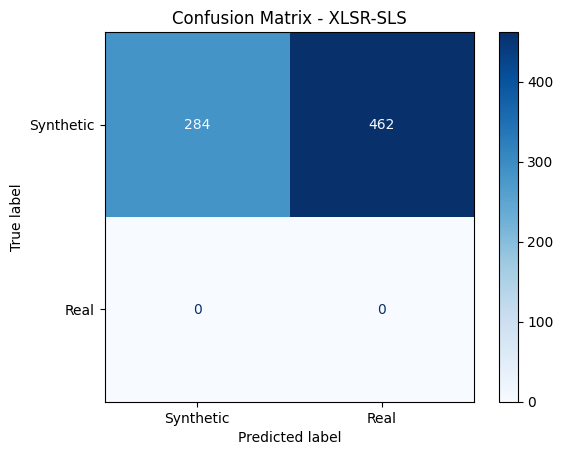

Testing spoof elevenmultilingualv2 tts samples


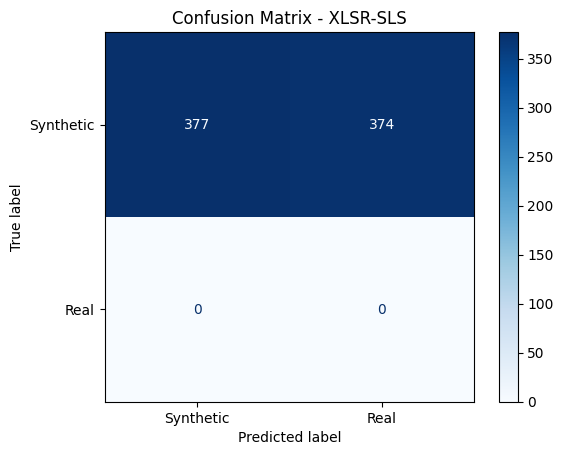

Testing spoof dupdub converted samples


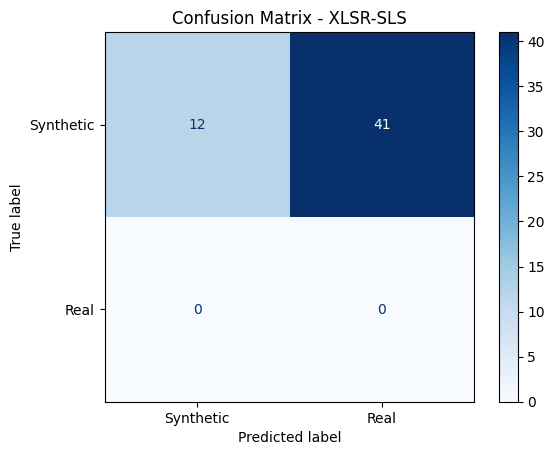

Testing spoof dupdub tts samples


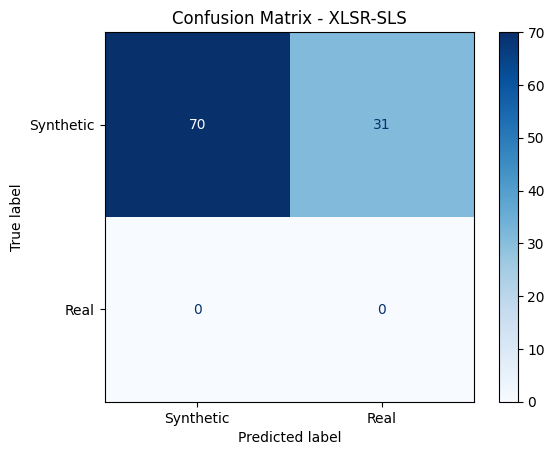

Testing spoof dupdub notindataset tts samples


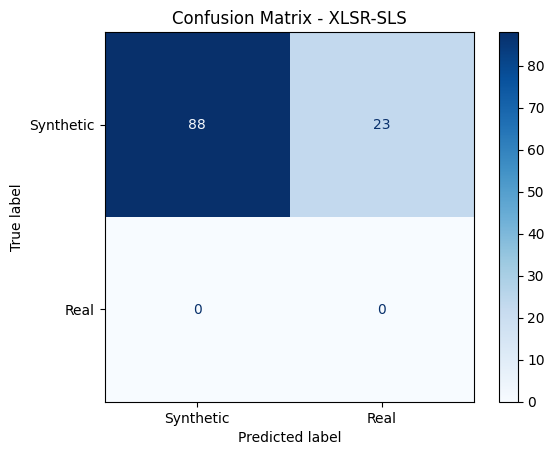

Testing spoof facebookmms converted samples


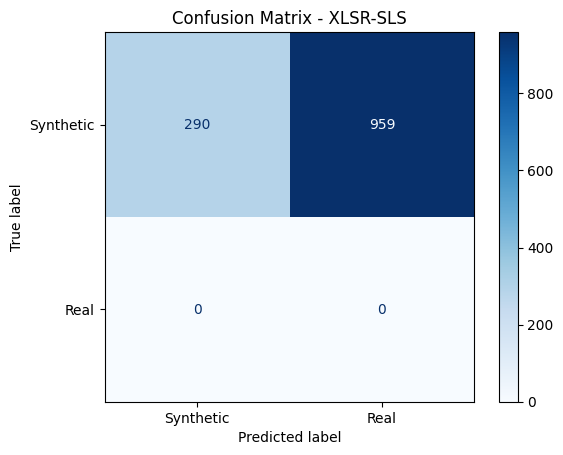

Testing spoof facebookmms tts samples


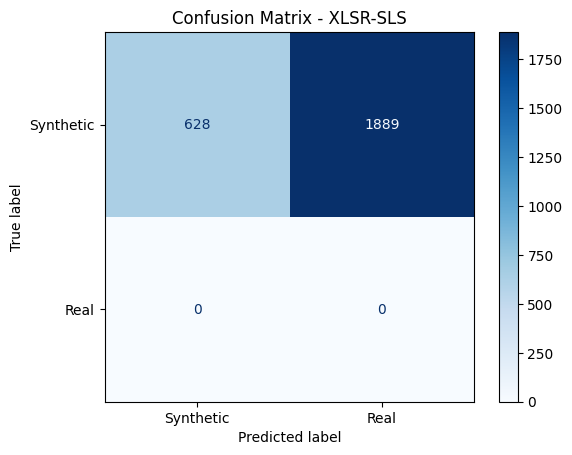

Testing spoof googletts converted samples


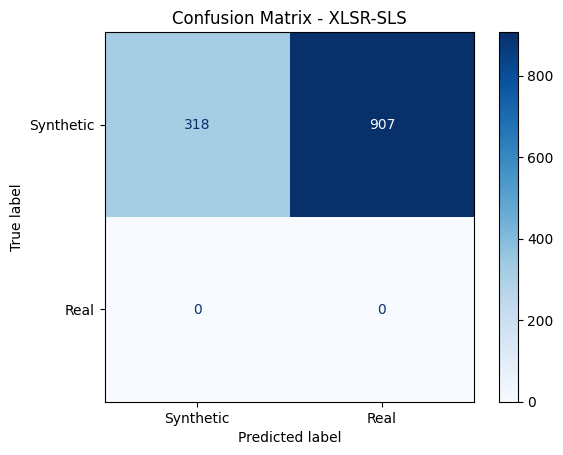

Testing spoof googletts tts samples


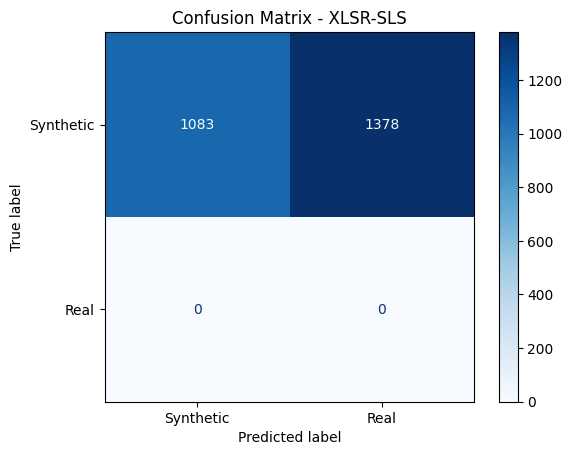

Testing spoof vits converted samples


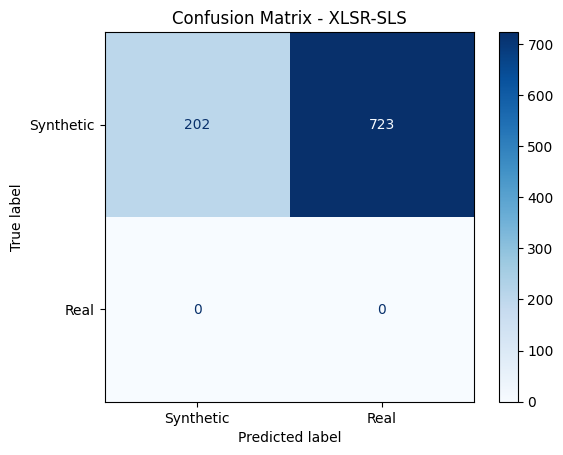

Testing spoof vits tts samples


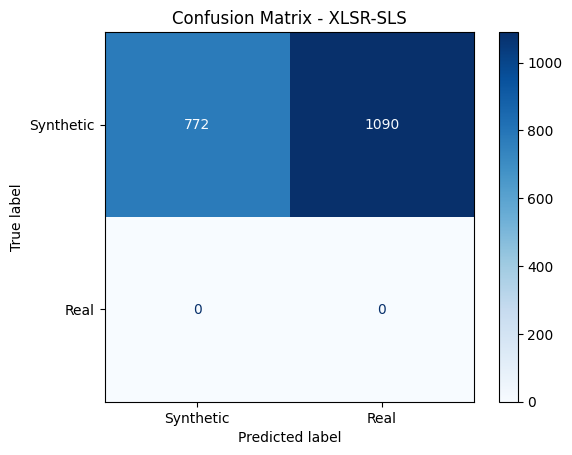

Testing bonafide commonvoice samples


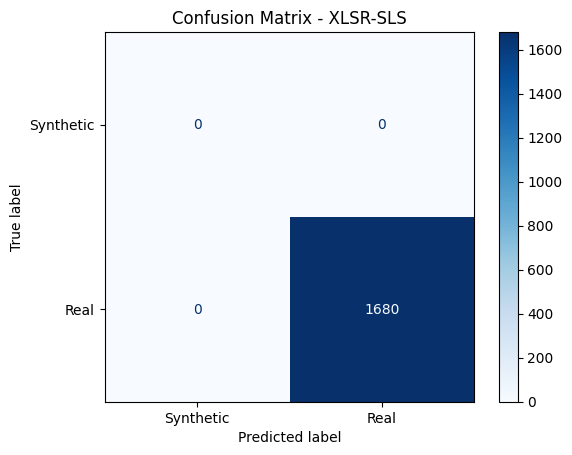

Testing bonafide prosa samples


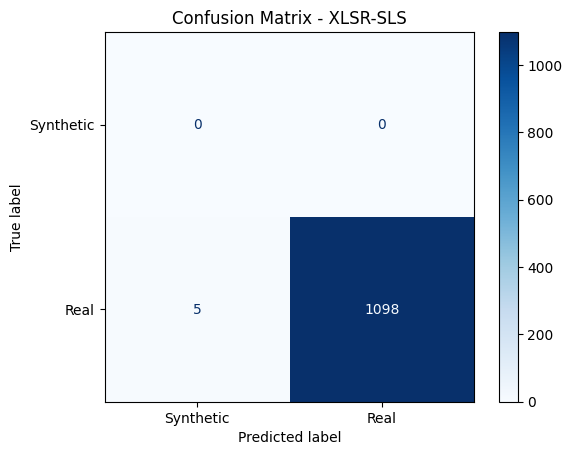

Testing spoof all samples


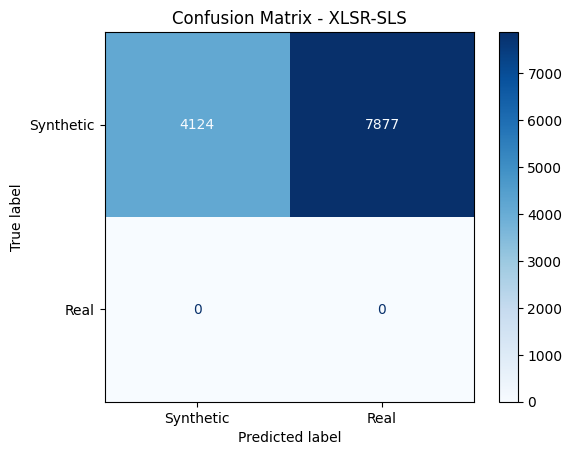

Testing bonafide all samples


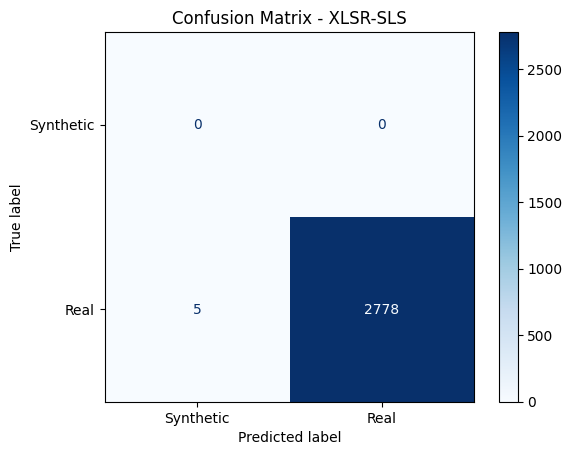

Testing seen all samples
              --> Test Acc: 47.23%
              --> Balanced Acc: 0.6412 | Precision: 0.3329
              --> Recall: 0.9982 | F1: 0.4992 | F2: 0.7131
              --> EER: 0.2381 | actDCF: 1.0000 | minDCF: 0.3710
              --> CLLR: 0.9504


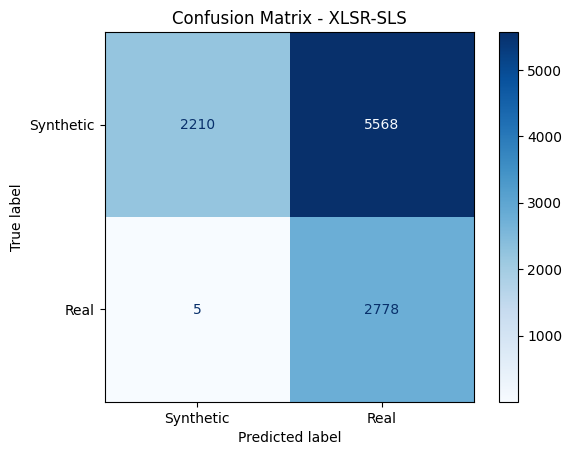

Testing unseen all samples (UID)


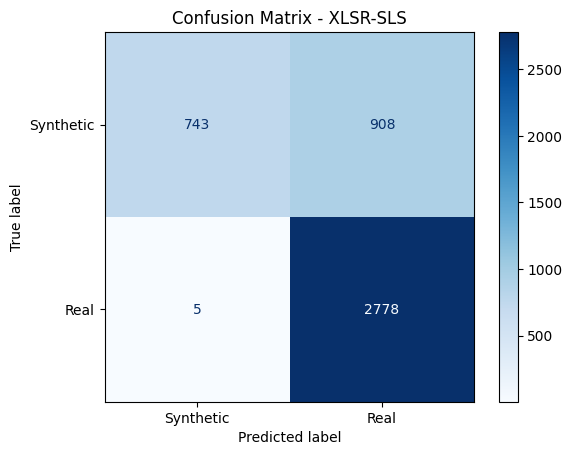

Testing unseen all samples (UID) w/ Google TTS
              --> Test Acc: 66.97%
              --> Balanced Acc: 0.7257 | Precision: 0.5461
              --> Recall: 0.9982 | F1: 0.7060 | F2: 0.8564
              --> EER: 0.1309 | actDCF: 1.0000 | minDCF: 0.2080
              --> CLLR: 0.9194


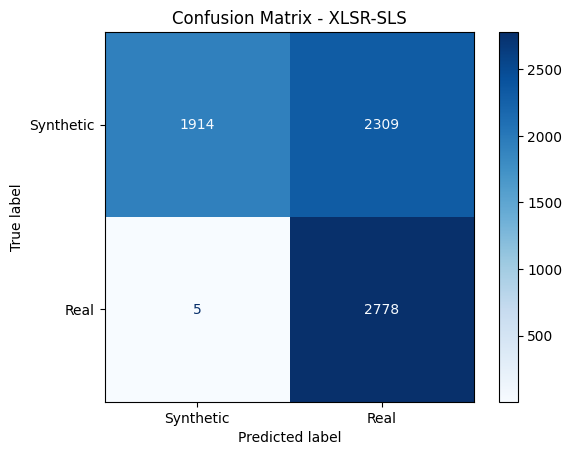

Testing unseen all samples (UnID)
              --> Test Acc: 99.03%
              --> Balanced Acc: 0.8955 | Precision: 0.9918
              --> Recall: 0.9982 | F1: 0.9950 | F2: 0.9969
              --> EER: 0.1013 | actDCF: 1.0000 | minDCF: 0.1099
              --> CLLR: 0.8606


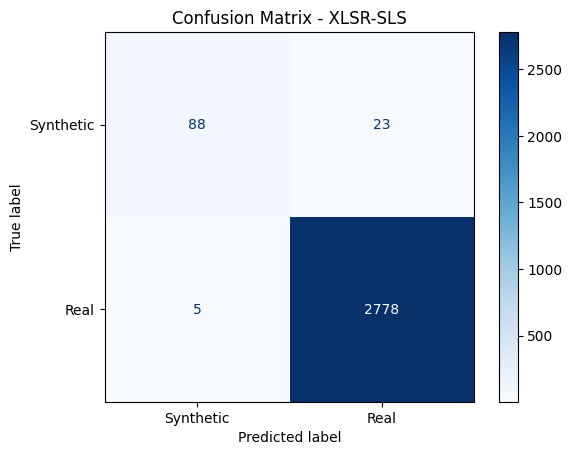

In [5]:
# Import XLSR-SLS diff pipeline model
from classes.models.XLSR_SLS.model_XLSR_SLS_diff_pipeline import XLSRSLSDiffPipeline

# Model configuration
xlsr_sls_diff_pipeline_model_config = {
    'cp_path': 'xlsr2_300m.pt',       # Path to pretrained XLSR model
    'fine_tune_ssl': True,            # Whether to fine-tune SSL model
    'nb_patho_features': 24           # Number of pathological features
}

device = "cuda" if torch.cuda.is_available() else "cpu"

# Clear GPU cache before creating model
torch.cuda.empty_cache()

# --- Initialize model directly on GPU (same as training) ---
# This avoids cuDNN initialization issues with Hugging Face models
model = XLSRSLSDiffPipeline(xlsr_sls_diff_pipeline_model_config, device).to(device)
optimizer = Adam(model.parameters(), lr=learning_rate)
scaler = GradScaler()

# --- Load the model checkpoint ---
# Load to CPU first to avoid memory issues, but model is already on GPU
start_epoch = load_model_xlsr_sls(
    model, optimizer, scaler,
    path=r"pretrained_weights/diff_pipeline/XLSR_SLS/xlsr_sls_diff_pipeline-ep_30-bs_32-lr_1e-06.pth",
    device='cpu',  # Load checkpoint to CPU
    load_optimizer=False  # Skip loading optimizer for inference
)

# Ensure model is in eval mode
model.eval()

# Clear cache after model loading
torch.cuda.empty_cache()

# With batch_size=8, no chunking needed - process batches directly
for key, test_sample in combined_test_samples_dataloaders.items():
    print(f"Testing {key}")
    if key in main_keys:
        predictions, targets, metrics = test_xlsr_sls(model, test_sample, device=device)
    else:
        predictions = test_xlsr_sls_with_loaders(model, test_sample, device=device)
    torch.cuda.empty_cache()